# Lab 6: Building a RAG Pipeline — From Ingestion to Generation

**Part 4 — Retrieval-Augmented Generation (RAG)**

---

## Objectives

In this lab we build a **complete RAG system** from scratch, covering every stage of the pipeline:

1. **Ingest** documents from multiple sources (PDF, Markdown, Web)
2. **Chunk** documents with metadata preservation
3. **Embed** chunks into vector representations
4. **Index** embeddings in a Vector / Hybrid store
5. **Retrieve** the top-*k* most relevant chunks for a query
6. **Rerank** (optional) to improve precision
7. **Augment** the prompt with retrieved context
8. **Generate** a grounded answer with citations via an LLM

Then, in **Part 2**, we build a **Graph RAG** system that extracts entities and relationships, constructs a knowledge graph, and performs graph-augmented retrieval.

---

### RAG Pipeline Overview

```
┌──────────────┐    ┌──────────────┐    ┌──────────────┐    ┌────────────────┐
│  Ingestion   │───▶│  Chunking    │───▶│  Embeddings  │───▶│ Vector/Hybrid  │
│ PDF, MD, Web │    │ + metadata   │    │   vectors    │    │    Index       │
└──────────────┘    └──────────────┘    └──────────────┘    └────────────────┘

┌──────────────┐    ┌──────────────┐    ┌──────────────┐    ┌────────────────┐
│  Retrieval   │───▶│  Reranking   │───▶│   Prompt     │───▶│     LLM       │
│   top-k      │    │  (optional)  │    │ augmentation │    │  generation   │
└──────────────┘    └──────────────┘    └──────────────┘    └────────────────┘
```

### Key Principle

> **Answer quality is bounded by retrieval quality.** Better generation cannot fully compensate for poor evidence.

## 0. Environment Setup

In [1]:
# Install dependencies (uncomment on Google Colab)
!pip install chromadb sentence-transformers rank_bm25
!pip install pymupdf beautifulsoup4 requests
!pip install tiktoken ollama
!pip install networkx matplotlib seaborn

# ─── Ollama setup ───────────────────────────────────────────────────────────
# This notebook uses GLM-4.7-Flash via Ollama (100% free, runs locally).
# 1. Install Ollama: https://ollama.com/download
# 2. Pull the model:  ollama pull glm-4.7-flash
# 3. Ollama runs automatically in the background on http://localhost:11434

In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["OBJC_DISABLE_INITIALIZE_FORK_SAFETY"] = "YES"
import json
import hashlib
import warnings
import textwrap
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ollama

warnings.filterwarnings('ignore')

LLM_MODEL = "glm-4.7-flash:latest"

# Verify Ollama is running and model is available
try:
    models = ollama.list()
    model_names = [m.model for m in models.models]
    if any("glm-4.7-flash" in m for m in model_names):
        print(f"Ollama + {LLM_MODEL} ready.")
    else:
        print(f"{LLM_MODEL} not found. Run: ollama pull glm-4.7-flash")
        print(f"Available models: {model_names}")
except Exception as e:
    print(f"Ollama not reachable: {e}")
    print("Install Ollama from https://ollama.com/download, then run: ollama pull glm-4.7-flash")

Ollama + glm-4.7-flash:latest ready.


---

# PART 1 — Classic RAG Pipeline

---

## Step 1: Data Ingestion

A production RAG system must handle **heterogeneous data sources**. We demonstrate ingestion from the three most common formats:

| Source | Challenge | Tool |
|--------|-----------|------|
| **PDF** | Multi-column layouts, tables, headers/footers | PyMuPDF (`fitz`) |
| **Markdown** | Preserve heading hierarchy for metadata | Native Python |
| **Web** | HTML parsing, boilerplate removal | BeautifulSoup + requests |

For each source we extract:
- **Raw text** — the content itself
- **Metadata** — source name, page number, section title, URL, date

Metadata is critical: it enables **filtering at retrieval time** (e.g., "only search documents from 2024") and **source attribution** in generated answers.

In [3]:
import fitz  # PyMuPDF
import requests
from bs4 import BeautifulSoup
from dataclasses import dataclass, field
from typing import List, Dict, Optional


@dataclass
class Document:
    """A unified document representation regardless of source format."""
    text: str
    metadata: Dict[str, str] = field(default_factory=dict)
    doc_id: str = ""

    def __post_init__(self):
        if not self.doc_id:
            self.doc_id = hashlib.md5(self.text[:200].encode()).hexdigest()[:8]


# ── PDF Ingestion ──────────────────────────────────────────────────────────
def ingest_pdf(path: str) -> List[Document]:
    """Extract text page-by-page from a PDF using PyMuPDF."""
    docs = []
    pdf = fitz.open(path)
    for page_num in range(len(pdf)):
        page = pdf[page_num]
        text = page.get_text("text").strip()
        if text:
            docs.append(Document(
                text=text,
                metadata={
                    "source": Path(path).name,
                    "format": "pdf",
                    "page": str(page_num + 1),
                    "total_pages": str(len(pdf)),
                }
            ))
    pdf.close()
    return docs


# ── Markdown Ingestion ─────────────────────────────────────────────────────
def ingest_markdown(path: str) -> List[Document]:
    """Split a Markdown file by top-level headings (## sections)."""
    text = Path(path).read_text(encoding="utf-8")
    sections = []
    current_heading = "Introduction"
    current_lines = []

    for line in text.split("\n"):
        if line.startswith("## "):
            if current_lines:
                sections.append((current_heading, "\n".join(current_lines).strip()))
            current_heading = line.lstrip("# ").strip()
            current_lines = []
        else:
            current_lines.append(line)

    if current_lines:
        sections.append((current_heading, "\n".join(current_lines).strip()))

    docs = []
    for heading, body in sections:
        if body:
            docs.append(Document(
                text=body,
                metadata={
                    "source": Path(path).name,
                    "format": "markdown",
                    "section": heading,
                }
            ))
    return docs


# ── Web Ingestion ──────────────────────────────────────────────────────────
def ingest_web(url: str) -> List[Document]:
    """Fetch a web page and extract main text content."""
    resp = requests.get(url, timeout=15, headers={"User-Agent": "RAG-Lab/1.0"})
    resp.raise_for_status()
    soup = BeautifulSoup(resp.text, "html.parser")

    # Remove script/style elements
    for tag in soup(["script", "style", "nav", "footer", "header"]):
        tag.decompose()

    # Extract paragraphs
    paragraphs = [p.get_text(strip=True) for p in soup.find_all("p") if len(p.get_text(strip=True)) > 50]
    text = "\n\n".join(paragraphs)

    if text:
        return [Document(
            text=text,
            metadata={
                "source": url,
                "format": "web",
                "title": soup.title.string if soup.title else "Unknown",
            }
        )]
    return []


print("Ingestion functions defined.")

Ingestion functions defined.


### 1.1 Create Sample Documents

For this lab, we create a small corpus of documents about **Artificial Intelligence** from multiple sources. This simulates a real enterprise scenario where knowledge is scattered across formats.

In [4]:
# ── Create sample Markdown documents ──────────────────────────────────────
# We simulate a multi-document corpus about AI topics

sample_docs_dir = Path("sample_data")
sample_docs_dir.mkdir(exist_ok=True)

# Document 1: Transformer Architecture
(sample_docs_dir / "transformers.md").write_text("""\
# Transformer Architecture

## Overview
The Transformer architecture was introduced by Vaswani et al. in the 2017 paper
"Attention Is All You Need". It replaced recurrent neural networks (RNNs) with
self-attention mechanisms, enabling parallel processing of sequences.

The key innovation is scaled dot-product attention, which computes attention
weights between all pairs of tokens simultaneously. This allows capturing
long-range dependencies without the vanishing gradient problem.

## Self-Attention Mechanism
Self-attention computes three matrices from the input: Query (Q), Key (K), and
Value (V). The attention output is computed as softmax(QK^T / sqrt(d_k)) * V.

Multi-head attention runs multiple attention operations in parallel, each with
different learned projections. This allows the model to attend to information
from different representation subspaces at different positions.

## Encoder-Decoder Structure
The original Transformer has an encoder-decoder structure. The encoder processes
the input sequence bidirectionally. The decoder generates the output sequence
autoregressively, attending to both its own previous outputs and the encoder's
representations via cross-attention.

Modern variants include encoder-only models (BERT), decoder-only models (GPT),
and encoder-decoder models (T5, BART).

## Positional Encoding
Since self-attention is permutation-invariant, positional information must be
injected explicitly. The original paper uses sinusoidal positional encodings.
Modern models often use learned positional embeddings or relative position
encodings like RoPE (Rotary Position Embedding) and ALiBi.
""", encoding="utf-8")

# Document 2: RAG Systems
(sample_docs_dir / "rag_systems.md").write_text("""\
# Retrieval-Augmented Generation

## Definition
Retrieval-Augmented Generation (RAG) combines an information retrieval layer with
a language model so that responses are generated from retrieved evidence instead
of relying only on parametric memory. The canonical paper by Lewis et al. (2020)
introduced this paradigm for knowledge-intensive NLP tasks.

RAG systems split knowledge into parametric memory (model weights, frozen at
training time) and non-parametric memory (document index, updatable at any time).

## Why RAG Matters
Pure LLMs suffer from knowledge cutoff, hallucinations under uncertainty, and
inability to access private enterprise data. RAG addresses these by grounding
generation in retrieved evidence, enabling source attribution and freshness.

In production, RAG reduces hallucination rates by 40-60% compared to vanilla
LLM prompting, according to industry benchmarks.

## Chunking Strategies
Chunking is the most underestimated quality lever in RAG. Strategies include:
- Fixed-size (token-based): window of 256-512 tokens with 10-20% overlap
- Recursive splitting: split by hierarchical separators (paragraphs, sentences)
- Semantic chunking: segment by embedding similarity between adjacent passages
- Document-aware: respect document structure (headings, sections, code blocks)

The optimal chunk size depends on the use case: smaller chunks (256 tokens) favor
precision, while larger chunks (1024 tokens) preserve more context.

## Hybrid Retrieval
Hybrid retrieval combines sparse methods (BM25/TF-IDF for exact keyword matching)
with dense methods (embedding similarity for semantic matching). Results are fused
using Reciprocal Rank Fusion (RRF). This is the recommended approach for
production systems as it balances recall and robustness.

## Evaluation
RAG evaluation requires both component-level and end-to-end metrics:
- Retrieval: Recall@k, Hit Rate, MRR, nDCG
- Generation: Faithfulness, Answer Relevancy (via Ragas framework)
- Context: Context Precision, Context Recall
- Operations: latency p50/p95, cost per query, fallback rate
""", encoding="utf-8")

# Document 3: LLM Fine-tuning
(sample_docs_dir / "finetuning.md").write_text("""\
# LLM Fine-Tuning

## When to Fine-Tune vs RAG
Fine-tuning modifies model weights to adapt behavior (tone, format, domain
language). RAG provides dynamic knowledge access. They are complementary:
- Need fresh knowledge → RAG
- Need specific behavior/style → Fine-tuning
- Need both → Hybrid (fine-tune for behavior + RAG for knowledge)

## LoRA and QLoRA
Low-Rank Adaptation (LoRA) freezes the pre-trained model and injects trainable
rank decomposition matrices into each Transformer layer. Instead of updating the
full weight matrix W, LoRA learns two small matrices A and B such that the update
is W + BA, where B has shape (d, r) and A has shape (r, d) with r << d.

QLoRA combines LoRA with 4-bit quantization of the base model, enabling
fine-tuning of 65B parameter models on a single 48GB GPU. This dramatically
reduces the hardware requirements for fine-tuning.

## RLHF and DPO
Reinforcement Learning from Human Feedback (RLHF) trains a reward model from
human preferences, then optimizes the LLM policy via PPO. Direct Preference
Optimization (DPO) simplifies this by directly optimizing preferences without
a separate reward model, using a classification loss on preference pairs.

## Evaluation of Fine-Tuned Models
Fine-tuned models should be evaluated on:
- Task-specific benchmarks (accuracy, F1, BLEU, ROUGE)
- Safety and alignment checks (TruthfulQA, toxicity)
- Catastrophic forgetting tests (performance on original capabilities)
- Human evaluation for subjective quality (fluency, helpfulness)
""", encoding="utf-8")

# Document 4: Vector Databases
(sample_docs_dir / "vector_databases.md").write_text("""\
# Vector Databases and Indexing

## Why Vector Databases
Vector databases store high-dimensional embeddings and enable fast approximate
nearest neighbor (ANN) search. Exact search has O(n) complexity, which is too
slow for millions of vectors. ANN algorithms trade a small amount of accuracy
for orders-of-magnitude speedup.

## HNSW Algorithm
Hierarchical Navigable Small World (HNSW) is the most popular ANN algorithm.
It builds a multi-layer graph where each layer is a navigable small-world network.
Search starts at the top layer (sparse, long-range connections) and progressively
refines through lower layers (dense, short-range connections).

HNSW provides excellent recall (>95%) with millisecond-level latency for
collections of millions of vectors. Key parameters are M (number of connections)
and efConstruction (build-time quality vs speed tradeoff).

## Popular Solutions
- Chroma: embedded/server mode, simple API, good for prototyping
- FAISS (Meta): library-level, extremely fast, GPU support, no native persistence
- Pinecone: managed cloud, serverless scaling, metadata filtering
- Weaviate: open-source, native hybrid search, GraphQL API
- Qdrant: open-source, advanced filtering, gRPC, production-ready
- Milvus: open-source, highly scalable, multi-index support

## Similarity Metrics
The three main metrics for vector similarity are:
- Cosine similarity: measures angle between vectors, insensitive to magnitude
- Dot product: cosine × norms, useful when magnitude encodes importance
- Euclidean distance: geometric distance, less common in RAG

Important: the similarity metric must match what the embedding model was trained
with. If the model uses cosine similarity during training, index with cosine.
""", encoding="utf-8")

print(f"Created {len(list(sample_docs_dir.glob('*.md')))} sample Markdown documents in {sample_docs_dir}/")

Created 4 sample Markdown documents in sample_data/


In [5]:
# ── Ingest all documents ──────────────────────────────────────────────────
all_documents = []

# Ingest Markdown files
for md_file in sorted(sample_docs_dir.glob("*.md")):
    docs = ingest_markdown(str(md_file))
    all_documents.extend(docs)
    print(f"  📄 {md_file.name}: {len(docs)} sections")

# Ingest from Web (Wikipedia article on RAG)
try:
    web_url = "https://en.wikipedia.org/wiki/Retrieval-augmented_generation"
    web_docs = ingest_web(web_url)
    all_documents.extend(web_docs)
    print(f"  🌐 Wikipedia RAG article: {len(web_docs)} document(s)")
except Exception as e:
    print(f"  ⚠️  Web ingestion skipped (no internet?): {e}")

print(f"\nTotal documents ingested: {len(all_documents)}")
for doc in all_documents[:3]:
    print(f"  [{doc.doc_id}] {doc.metadata.get('source', '?')} | "
          f"{doc.metadata.get('section', doc.metadata.get('format', '?'))} | "
          f"{len(doc.text)} chars")

  📄 finetuning.md: 5 sections
  📄 rag_systems.md: 6 sections
  📄 transformers.md: 5 sections
  📄 vector_databases.md: 5 sections
  🌐 Wikipedia RAG article: 1 document(s)

Total documents ingested: 22
  [157f4276] finetuning.md | Introduction | 17 chars
  [591668fa] finetuning.md | When to Fine-Tune vs RAG | 288 chars
  [d2c647bf] finetuning.md | LoRA and QLoRA | 513 chars


## Step 3: Embeddings — Vectorizing Chunks

Embeddings convert text into dense vectors that capture **semantic meaning**. Two texts about the same topic will have similar vectors, even if they use different words.

**Important considerations:**
- Embeddings encode semantic proximity, **not factual truth**
- Performance varies by language, domain, and text length
- Always validate the embedding model on your actual data

We use `sentence-transformers/all-MiniLM-L6-v2` — a free, open-source model (384 dimensions, fast). No API key needed.

| Model | Dimensions | License | Notes |
|-------|-----------|---------|-------|
| **all-MiniLM-L6-v2** | 384 | Apache 2.0 | Fast, lightweight, good default |
| **all-mpnet-base-v2** | 768 | Apache 2.0 | Better quality, slower |
| **multilingual-e5-large** | 1024 | MIT | Best for multilingual corpora |

In [6]:
import tiktoken


@dataclass
class Chunk:
    """A text chunk with its parent document metadata."""
    text: str
    metadata: Dict[str, str] = field(default_factory=dict)
    chunk_id: str = ""

    def __post_init__(self):
        if not self.chunk_id:
            self.chunk_id = hashlib.md5(self.text[:100].encode()).hexdigest()[:8]


# ── Tokenizer for counting tokens ──────────────────────────────────────────
enc = tiktoken.get_encoding("cl100k_base")  # GPT-4 / text-embedding-3 tokenizer

def count_tokens(text: str) -> int:
    return len(enc.encode(text))


# ── Strategy 1: Fixed-size chunking ────────────────────────────────────────
def chunk_fixed_size(doc: Document, chunk_size: int = 256, overlap: int = 50) -> List[Chunk]:
    """Split document into fixed-size token windows with overlap."""
    tokens = enc.encode(doc.text)
    chunks = []
    start = 0
    while start < len(tokens):
        end = start + chunk_size
        chunk_tokens = tokens[start:end]
        chunk_text = enc.decode(chunk_tokens)
        chunks.append(Chunk(
            text=chunk_text,
            metadata={**doc.metadata, "chunk_strategy": "fixed_size",
                      "chunk_index": str(len(chunks))},
        ))
        start += chunk_size - overlap
    return chunks


# ── Strategy 2: Recursive splitting ────────────────────────────────────────
def chunk_recursive(doc: Document, chunk_size: int = 256, overlap: int = 50) -> List[Chunk]:
    """Split by paragraph boundaries, then sentence boundaries if needed."""
    separators = ["\n\n", "\n", ". ", " "]
    
    def _split(text: str, sep_idx: int = 0) -> List[str]:
        if count_tokens(text) <= chunk_size:
            return [text] if text.strip() else []
        if sep_idx >= len(separators):
            # Fallback to fixed-size
            tokens = enc.encode(text)
            result = []
            for i in range(0, len(tokens), chunk_size - overlap):
                result.append(enc.decode(tokens[i:i + chunk_size]))
            return result

        sep = separators[sep_idx]
        parts = text.split(sep)
        result = []
        current = ""
        for part in parts:
            candidate = current + sep + part if current else part
            if count_tokens(candidate) <= chunk_size:
                current = candidate
            else:
                if current:
                    result.append(current)
                if count_tokens(part) > chunk_size:
                    result.extend(_split(part, sep_idx + 1))
                    current = ""
                else:
                    current = part
        if current:
            result.append(current)
        return result

    texts = _split(doc.text)
    return [
        Chunk(
            text=t.strip(),
            metadata={**doc.metadata, "chunk_strategy": "recursive",
                      "chunk_index": str(i)},
        )
        for i, t in enumerate(texts) if t.strip()
    ]


print("Chunking functions defined.")

Chunking functions defined.


In [7]:
# ── Apply recursive chunking to all documents ─────────────────────────────
CHUNK_SIZE = 256   # tokens
CHUNK_OVERLAP = 50 # tokens

all_chunks = []
for doc in all_documents:
    chunks = chunk_recursive(doc, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP)
    all_chunks.extend(chunks)

print(f"Total chunks created: {len(all_chunks)}")
print(f"Average chunk size: {np.mean([count_tokens(c.text) for c in all_chunks]):.0f} tokens")
print(f"Min / Max: {min(count_tokens(c.text) for c in all_chunks)} / "
      f"{max(count_tokens(c.text) for c in all_chunks)} tokens")

# Show a few chunks with their metadata
print("\n--- Sample Chunks ---")
for c in all_chunks[:3]:
    print(f"\n[{c.chunk_id}] source={c.metadata.get('source', '?')} | "
          f"section={c.metadata.get('section', '?')} | {count_tokens(c.text)} tokens")
    print(textwrap.shorten(c.text, width=120, placeholder="..."))

Total chunks created: 29
Average chunk size: 103 tokens
Min / Max: 3 / 255 tokens

--- Sample Chunks ---

[157f4276] source=finetuning.md | section=Introduction | 6 tokens
# LLM Fine-Tuning

[25dfe595] source=finetuning.md | section=When to Fine-Tune vs RAG | 64 tokens
Fine-tuning modifies model weights to adapt behavior (tone, format, domain language). RAG provides dynamic knowledge...

[c68871f0] source=finetuning.md | section=LoRA and QLoRA | 129 tokens
Low-Rank Adaptation (LoRA) freezes the pre-trained model and injects trainable rank decomposition matrices into each...


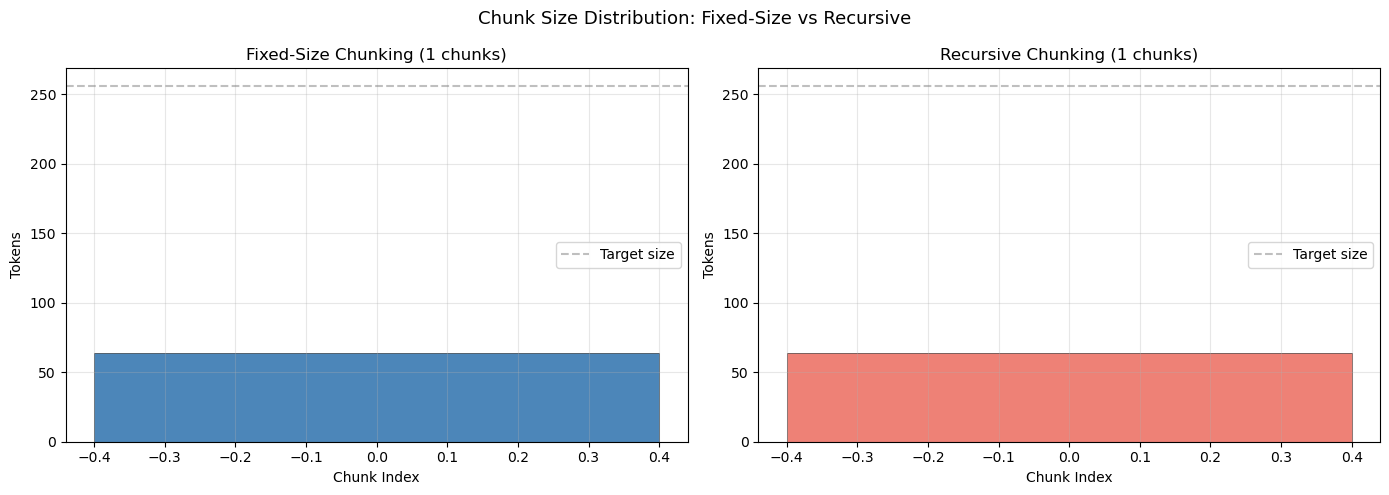

Fixed-size: 1 chunks, avg 64 tokens
Recursive:  1 chunks, avg 64 tokens

Recursive chunking respects paragraph boundaries → more coherent chunks.


In [8]:
# ── Compare chunking strategies ───────────────────────────────────────────
# Use a single document to compare fixed-size vs recursive
sample_doc = all_documents[1]  # RAG systems document

fixed_chunks = chunk_fixed_size(sample_doc, chunk_size=256, overlap=50)
recursive_chunks = chunk_recursive(sample_doc, chunk_size=256, overlap=50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, chunks, name, color in [
    (axes[0], fixed_chunks, "Fixed-Size", "#00539C"),
    (axes[1], recursive_chunks, "Recursive", "#E74C3C"),
]:
    sizes = [count_tokens(c.text) for c in chunks]
    ax.bar(range(len(sizes)), sizes, color=color, alpha=0.7, edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Chunk Index")
    ax.set_ylabel("Tokens")
    ax.set_title(f"{name} Chunking ({len(chunks)} chunks)")
    ax.axhline(y=256, color="gray", linestyle="--", alpha=0.5, label="Target size")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Chunk Size Distribution: Fixed-Size vs Recursive", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Fixed-size: {len(fixed_chunks)} chunks, avg {np.mean([count_tokens(c.text) for c in fixed_chunks]):.0f} tokens")
print(f"Recursive:  {len(recursive_chunks)} chunks, avg {np.mean([count_tokens(c.text) for c in recursive_chunks]):.0f} tokens")
print("\nRecursive chunking respects paragraph boundaries → more coherent chunks.")

## Step 3: Embeddings — Vectorizing Chunks

Embeddings convert text into dense vectors that capture **semantic meaning**. Two texts about the same topic will have similar vectors, even if they use different words.

**Important considerations:**
- Embeddings encode semantic proximity, **not factual truth**
- Performance varies by language, domain, and text length
- Always validate the embedding model on your actual data

We use `sentence-transformers/all-MiniLM-L6-v2` (open-source, 384 dimensions, fast) for this lab. In production, you might use OpenAI `text-embedding-3-small` or Cohere Embed v3 depending on your quality/cost/privacy requirements.

In [9]:
from sentence_transformers import SentenceTransformer

# Load a lightweight open-source embedding model
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

print(f"Model: all-MiniLM-L6-v2")
print(f"Embedding dimensions: {embed_model.get_sentence_embedding_dimension()}")
print(f"Max sequence length: {embed_model.max_seq_length}")

Model: all-MiniLM-L6-v2
Embedding dimensions: 384
Max sequence length: 256


In [10]:
# ── Embed all chunks ──────────────────────────────────────────────────────
chunk_texts = [c.text for c in all_chunks]
embeddings = embed_model.encode(chunk_texts, show_progress_bar=True, normalize_embeddings=True)

print(f"\nEmbeddings shape: {embeddings.shape}")
print(f"Each chunk is now a {embeddings.shape[1]}-dimensional vector.")
print(f"Vectors are L2-normalized → cosine similarity = dot product.")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Embeddings shape: (29, 384)
Each chunk is now a 384-dimensional vector.
Vectors are L2-normalized → cosine similarity = dot product.


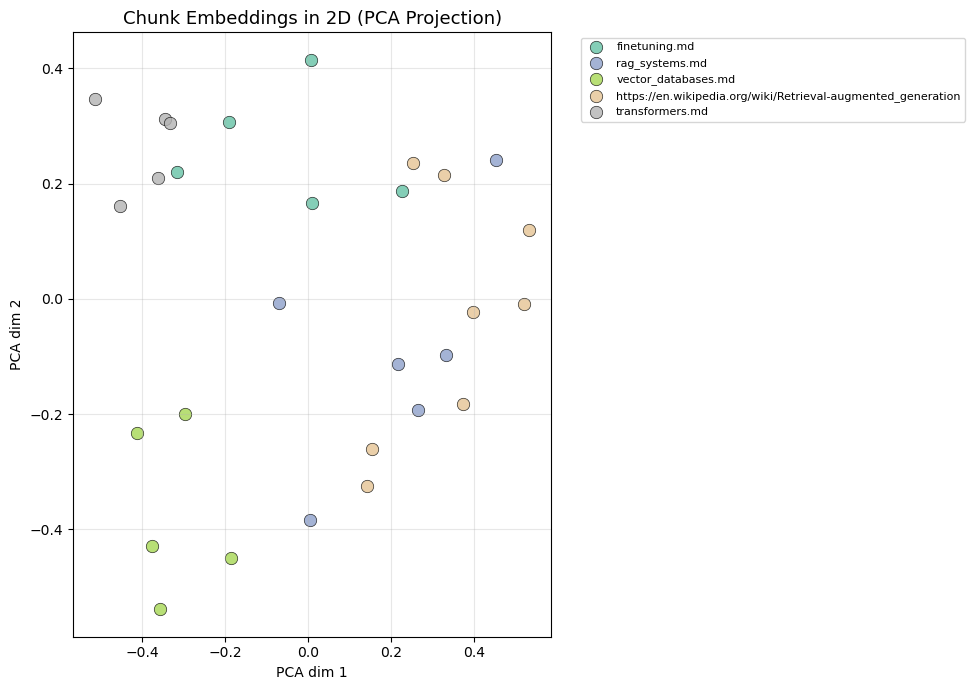

Chunks from the same document tend to cluster together in embedding space.
Thematically related chunks from different documents may also be close.


In [11]:
# ── Visualize embedding space ─────────────────────────────────────────────
# Use PCA to project 384D → 2D for visualization (safer on Apple Silicon than t-SNE)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings)

# Color by source document
sources = [c.metadata.get("source", "unknown") for c in all_chunks]
unique_sources = list(set(sources))
colors = plt.cm.Set2(np.linspace(0, 1, len(unique_sources)))
source_to_color = {s: colors[i] for i, s in enumerate(unique_sources)}

fig, ax = plt.subplots(figsize=(10, 7))
for source in unique_sources:
    mask = [s == source for s in sources]
    points = embeddings_2d[mask]
    ax.scatter(points[:, 0], points[:, 1], c=[source_to_color[source]],
               label=source, s=80, edgecolors="black", linewidth=0.5, alpha=0.8)

ax.set_title("Chunk Embeddings in 2D (PCA Projection)", fontsize=13)
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax.set_xlabel("PCA dim 1")
ax.set_ylabel("PCA dim 2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Chunks from the same document tend to cluster together in embedding space.")
print("Thematically related chunks from different documents may also be close.")


## Step 4: Vector / Hybrid Index

We store embeddings in **ChromaDB** (a lightweight vector database) and also build a **BM25 index** for keyword-based retrieval. Combining both gives us **hybrid retrieval**.

| Retrieval Type | Strengths | Weaknesses |
|---------------|-----------|------------|
| **Dense** (vector) | Semantic matching, paraphrase-robust | Can miss exact rare tokens |
| **Sparse** (BM25) | Exact keyword match, fast | Misses semantic paraphrases |
| **Hybrid** | Best of both worlds | More tuning complexity |

We fuse results using **Reciprocal Rank Fusion (RRF)**:

$$\text{RRF}(d) = \sum_{r \in \text{rankers}} \frac{1}{k + \text{rank}_r(d)}$$

where $k = 60$ is a constant that smooths the contribution of each ranker.

In [12]:
import chromadb
from rank_bm25 import BM25Okapi

# ── Vector Index (ChromaDB) ────────────────────────────────────────────────
chroma_client = chromadb.Client()  # In-memory for this lab

collection = chroma_client.create_collection(
    name="rag_lab",
    metadata={"hnsw:space": "cosine"}  # Use cosine similarity
)

# Add chunks to ChromaDB
collection.add(
    ids=[c.chunk_id for c in all_chunks],
    embeddings=embeddings.tolist(),
    documents=chunk_texts,
    metadatas=[c.metadata for c in all_chunks],
)

print(f"ChromaDB collection '{collection.name}': {collection.count()} vectors")

# ── BM25 Index (sparse retrieval) ──────────────────────────────────────────
tokenized_chunks = [text.lower().split() for text in chunk_texts]
bm25_index = BM25Okapi(tokenized_chunks)

print(f"BM25 index: {len(tokenized_chunks)} documents indexed")

ChromaDB collection 'rag_lab': 29 vectors
BM25 index: 29 documents indexed


## Step 5: Retrieval — top-*k*

We implement three retrieval modes and compare their results on the same query:
1. **Dense-only** — vector similarity via ChromaDB
2. **Sparse-only** — BM25 keyword matching
3. **Hybrid** — combine both with Reciprocal Rank Fusion

In [13]:
def retrieve_dense(query: str, top_k: int = 5) -> List[Dict]:
    """Dense retrieval using vector similarity (ChromaDB)."""
    query_embedding = embed_model.encode([query], normalize_embeddings=True).tolist()
    results = collection.query(
        query_embeddings=query_embedding,
        n_results=top_k,
        include=["documents", "metadatas", "distances"]
    )
    return [
        {"text": doc, "metadata": meta, "score": 1 - dist, "method": "dense"}
        for doc, meta, dist in zip(
            results["documents"][0], results["metadatas"][0], results["distances"][0]
        )
    ]


def retrieve_sparse(query: str, top_k: int = 5) -> List[Dict]:
    """Sparse retrieval using BM25."""
    query_tokens = query.lower().split()
    scores = bm25_index.get_scores(query_tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [
        {"text": all_chunks[i].text, "metadata": all_chunks[i].metadata,
         "score": scores[i], "method": "sparse"}
        for i in top_indices if scores[i] > 0
    ]


def retrieve_hybrid(query: str, top_k: int = 5, rrf_k: int = 60) -> List[Dict]:
    """Hybrid retrieval with Reciprocal Rank Fusion."""
    dense_results = retrieve_dense(query, top_k=top_k * 2)
    sparse_results = retrieve_sparse(query, top_k=top_k * 2)

    # Build RRF scores
    rrf_scores = {}
    doc_map = {}

    for rank, r in enumerate(dense_results):
        key = r["text"][:100]
        rrf_scores[key] = rrf_scores.get(key, 0) + 1 / (rrf_k + rank + 1)
        doc_map[key] = r

    for rank, r in enumerate(sparse_results):
        key = r["text"][:100]
        rrf_scores[key] = rrf_scores.get(key, 0) + 1 / (rrf_k + rank + 1)
        doc_map[key] = r

    # Sort by RRF score
    sorted_keys = sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:top_k]
    return [
        {**doc_map[k], "score": rrf_scores[k], "method": "hybrid"}
        for k in sorted_keys
    ]


print("Retrieval functions defined.")

Retrieval functions defined.


## Step 8: LLM Generation

The final step: send the augmented prompt to an LLM to generate a **grounded, cited answer**.

We use **GLM-4.7-Flash via Ollama** — a fast, capable LLM running locally on your machine. This is **completely free** with no API key required.

> **Why GLM-4.7-Flash?** The "Flash" variant is optimized for speed, which is important since we make multiple LLM calls (generation + entity extraction). It has strong instruction-following capabilities and handles JSON output well.

In [14]:
def generate_answer(prompt: str, model: str = LLM_MODEL) -> str:
    """Generate an answer using GLM-4.7-Flash via Ollama (local, free)."""
    try:
        response = ollama.chat(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            options={
                "temperature": 0.1,   # Low temperature for factual answers
                "num_predict": 500,   # Max tokens to generate
            },
        )
        return response.message.content
    except Exception as e:
        return (f"[LLM call failed: {e}]\n\n"
                "Make sure Ollama is running (ollama serve) "
                "and GLM-4.7-Flash is installed (ollama pull glm-4.7-flash).")


# ── Full RAG Pipeline: end-to-end ─────────────────────────────────────────
def rag_pipeline(query: str, top_k: int = 5, rerank_top_k: int = 3,
                 use_reranking: bool = True, retrieval_method: str = "hybrid") -> Dict:
    """Run the complete RAG pipeline."""
    # Step 1: Retrieve
    if retrieval_method == "dense":
        retrieved = retrieve_dense(query, top_k=top_k)
    elif retrieval_method == "sparse":
        retrieved = retrieve_sparse(query, top_k=top_k)
    else:
        retrieved = retrieve_hybrid(query, top_k=top_k)

    # Step 2: Rerank (optional)
    if use_reranking and retrieved:
        final_chunks = rerank(query, retrieved, top_k=rerank_top_k)
    else:
        final_chunks = retrieved[:rerank_top_k]

    # Step 3: Build prompt
    prompt = build_rag_prompt(query, final_chunks)

    # Step 4: Generate
    answer = generate_answer(prompt)

    return {
        "query": query,
        "retrieved_chunks": final_chunks,
        "prompt_tokens": count_tokens(prompt),
        "answer": answer,
    }


print(f"Full RAG pipeline ready (using {LLM_MODEL} via Ollama).")

Full RAG pipeline ready (using glm-4.7-flash:latest via Ollama).


In [15]:
from sentence_transformers import CrossEncoder

# Load cross-encoder reranker
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")


def rerank(query: str, results: List[Dict], top_k: int = 3) -> List[Dict]:
    """Rerank retrieved results using a cross-encoder."""
    if not results:
        return []
    pairs = [(query, r["text"]) for r in results]
    scores = reranker.predict(pairs)
    
    for r, score in zip(results, scores):
        r["rerank_score"] = float(score)
    
    reranked = sorted(results, key=lambda x: x["rerank_score"], reverse=True)
    return reranked[:top_k]


# ── Demonstrate reranking impact ──────────────────────────────────────────
query = "How does HNSW algorithm work for vector search?"
print(f"Query: '{query}'\n")

# Retrieve with hybrid
initial_results = retrieve_hybrid(query, top_k=8)
print("Before Reranking (Hybrid Retrieval):")
for i, r in enumerate(initial_results[:5]):
    print(f"  #{i+1} [{r['score']:.4f}] {textwrap.shorten(r['text'], width=90, placeholder='...')}")

# Rerank
reranked_results = rerank(query, initial_results, top_k=5)
print(f"\nAfter Reranking (Cross-Encoder):")
for i, r in enumerate(reranked_results[:5]):
    print(f"  #{i+1} [{r['rerank_score']:.4f}] {textwrap.shorten(r['text'], width=90, placeholder='...')}")

Query: 'How does HNSW algorithm work for vector search?'

Before Reranking (Hybrid Retrieval):
  #1 [0.0325] Hierarchical Navigable Small World (HNSW) is the most popular ANN algorithm. It builds...
  #2 [0.0320] Sometimes vector database searches can miss key facts needed to answer a user's...
  #3 [0.0317] # Vector Databases and Indexing
  #4 [0.0315] Vector databases store high-dimensional embeddings and enable fast approximate nearest...
  #5 [0.0301] These methods focus on the encoding of text as either dense or sparse vectors.Sparse...

After Reranking (Cross-Encoder):
  #1 [6.9761] Hierarchical Navigable Small World (HNSW) is the most popular ANN algorithm. It builds...
  #2 [1.8351] Vector databases store high-dimensional embeddings and enable fast approximate nearest...
  #3 [-1.0988] Sometimes vector database searches can miss key facts needed to answer a user's...
  #4 [-5.9002] # Vector Databases and Indexing
  #5 [-6.4841] Typically, the data to be referenced is converted 

## Step 7: Prompt Augmentation

Prompt augmentation inserts the retrieved chunks into a carefully designed prompt template. The key principles are:

1. **Answer ONLY from provided context** — prevent hallucination
2. **Cite sources** — enable verification and trust
3. **Explicit fallback** — say "insufficient evidence" rather than guessing
4. **Structure the context** — include metadata (source, section) so the LLM knows where information comes from

In [16]:
def build_rag_prompt(query: str, retrieved_chunks: List[Dict]) -> str:
    """Build a RAG prompt with retrieved context and citation instructions."""
    # Format context blocks with metadata
    context_blocks = []
    for i, chunk in enumerate(retrieved_chunks):
        source = chunk["metadata"].get("source", "unknown")
        section = chunk["metadata"].get("section", "")
        chunk_id = f"{source}:{section}" if section else source
        context_blocks.append(
            f"[Source {i+1}: {chunk_id}]\n{chunk['text']}"
        )

    context_str = "\n\n---\n\n".join(context_blocks)

    prompt = f"""You are an expert assistant. Answer the user's question using ONLY the provided context.

Rules:
- Answer ONLY from the provided context below.
- If the evidence is insufficient, say exactly: "Insufficient evidence in the provided context."
- Each factual claim must cite at least one source using [Source N] format.
- Be concise and direct.

Context:
{context_str}

Question: {query}

Answer:"""
    return prompt


# ── Build a prompt for our query ──────────────────────────────────────────
query = "What are the different chunking strategies for RAG and when should I use each?"
retrieved = retrieve_hybrid(query, top_k=5)
reranked = rerank(query, retrieved, top_k=3)

prompt = build_rag_prompt(query, reranked)
print(f"Prompt length: {count_tokens(prompt)} tokens\n")
print(prompt[:1500])
print("\n... [truncated for display]")

Prompt length: 769 tokens

You are an expert assistant. Answer the user's question using ONLY the provided context.

Rules:
- Answer ONLY from the provided context below.
- If the evidence is insufficient, say exactly: "Insufficient evidence in the provided context."
- Each factual claim must cite at least one source using [Source N] format.
- Be concise and direct.

Context:
[Source 1: rag_systems.md:Chunking Strategies]
Chunking is the most underestimated quality lever in RAG. Strategies include:
- Fixed-size (token-based): window of 256-512 tokens with 10-20% overlap
- Recursive splitting: split by hierarchical separators (paragraphs, sentences)
- Semantic chunking: segment by embedding similarity between adjacent passages
- Document-aware: respect document structure (headings, sections, code blocks)

The optimal chunk size depends on the use case: smaller chunks (256 tokens) favor
precision, while larger chunks (1024 tokens) preserve more context.

---

[Source 2: https://en.wikipe

## Step 8: LLM Generation

The final step: send the augmented prompt to an LLM to generate a **grounded, cited answer**.

We use OpenAI's API here. You can replace with any LLM (Claude, Mistral, local models via Ollama, etc.).

> **Note:** If you don't have an OpenAI API key, the generation step will show a simulated response. All prior steps (ingestion → retrieval → reranking → prompt building) work without an API key.

In [17]:
import networkx as nx
import re


@dataclass
class Entity:
    name: str
    entity_type: str  # TECHNOLOGY, CONCEPT, METHOD, PERSON, METRIC
    description: str = ""


@dataclass
class Relationship:
    source: str
    target: str
    relation: str  # e.g., "is_a", "uses", "part_of", "improves"
    description: str = ""


def extract_entities_llm(text: str, source: str = "") -> tuple:
    """Extract entities and relationships from text using GLM-4.7-Flash via Ollama."""
    extraction_prompt = f"""Extract entities and relationships from the following text.

Return a JSON object with two arrays:
- "entities": list of {{"name": str, "type": str, "description": str}}
  Types: TECHNOLOGY, CONCEPT, METHOD, PERSON, METRIC, FRAMEWORK
- "relationships": list of {{"source": str, "target": str, "relation": str, "description": str}}
  Relations: is_a, uses, part_of, improves, compares_to, evaluates, depends_on

Text:
{text[:2000]}

Return ONLY valid JSON, no markdown formatting, no explanation."""

    try:
        response = ollama.chat(
            model=LLM_MODEL,
            messages=[{"role": "user", "content": extraction_prompt}],
            options={"temperature": 0.0, "num_predict": 1500},
        )
        content = response.message.content.strip()
        # Clean markdown code blocks if present
        content = re.sub(r"```json?\n?", "", content)
        content = re.sub(r"```", "", content)
        data = json.loads(content)

        entities = [Entity(e["name"], e["type"], e.get("description", ""))
                    for e in data.get("entities", [])]
        relationships = [Relationship(r["source"], r["target"], r["relation"],
                                       r.get("description", ""))
                         for r in data.get("relationships", [])]
        return entities, relationships

    except Exception as e:
        print(f"  LLM extraction failed ({e}), using rule-based fallback")
        return extract_entities_rules(text, source)


def extract_entities_rules(text: str, source: str = "") -> tuple:
    """Rule-based fallback: extract known AI/ML entities from text."""
    known_entities = {
        # Technologies
        "Transformer": "TECHNOLOGY", "BERT": "TECHNOLOGY", "GPT": "TECHNOLOGY",
        "T5": "TECHNOLOGY", "BART": "TECHNOLOGY", "RNN": "TECHNOLOGY",
        "LSTM": "TECHNOLOGY", "LoRA": "METHOD", "QLoRA": "METHOD",
        "RLHF": "METHOD", "DPO": "METHOD", "PPO": "METHOD",
        # Concepts
        "RAG": "CONCEPT", "self-attention": "CONCEPT", "cross-attention": "CONCEPT",
        "fine-tuning": "CONCEPT", "embedding": "CONCEPT", "chunking": "CONCEPT",
        "BM25": "METHOD", "HNSW": "METHOD", "RoPE": "METHOD", "ALiBi": "METHOD",
        "hybrid retrieval": "CONCEPT", "reranking": "CONCEPT",
        # Vector DBs
        "ChromaDB": "TECHNOLOGY", "Chroma": "TECHNOLOGY", "FAISS": "TECHNOLOGY",
        "Pinecone": "TECHNOLOGY", "Weaviate": "TECHNOLOGY",
        "Qdrant": "TECHNOLOGY", "Milvus": "TECHNOLOGY",
        # Metrics
        "cosine similarity": "METRIC", "Recall@k": "METRIC",
        "MRR": "METRIC", "nDCG": "METRIC", "Faithfulness": "METRIC",
        # Frameworks
        "Ragas": "FRAMEWORK", "LangChain": "FRAMEWORK",
    }

    known_relations = [
        ("RAG", "embedding", "uses"),
        ("RAG", "chunking", "uses"),
        ("RAG", "BM25", "uses"),
        ("RAG", "reranking", "uses"),
        ("Transformer", "self-attention", "uses"),
        ("BERT", "Transformer", "is_a"),
        ("GPT", "Transformer", "is_a"),
        ("T5", "Transformer", "is_a"),
        ("HNSW", "FAISS", "part_of"),
        ("LoRA", "fine-tuning", "is_a"),
        ("QLoRA", "LoRA", "improves"),
        ("DPO", "RLHF", "improves"),
        ("hybrid retrieval", "BM25", "uses"),
        ("hybrid retrieval", "embedding", "uses"),
        ("Ragas", "RAG", "evaluates"),
        ("RoPE", "Transformer", "part_of"),
        ("cross-attention", "Transformer", "part_of"),
    ]

    text_lower = text.lower()
    found_entities = []
    for name, etype in known_entities.items():
        if name.lower() in text_lower:
            found_entities.append(Entity(name, etype))

    found_names = {e.name.lower() for e in found_entities}
    found_rels = []
    for src, tgt, rel in known_relations:
        if src.lower() in found_names and tgt.lower() in found_names:
            found_rels.append(Relationship(src, tgt, rel))

    return found_entities, found_rels


print(f"Entity extraction functions defined (using {LLM_MODEL} via Ollama).")

Entity extraction functions defined (using glm-4.7-flash:latest via Ollama).


In [18]:
# ── Test the full RAG pipeline with multiple queries ──────────────────────
test_queries = [
    "What chunking strategies are used in RAG systems and when should I use each?",
    "How does HNSW work and what are its key parameters?",
    "When should I use RAG vs fine-tuning?",
    "What is the difference between sparse and dense retrieval?",
    "What is quantum computing?",  # Out of scope — should trigger fallback
]

for q in test_queries:
    print(f"\n{'='*80}")
    print(f"Q: {q}")
    print(f"{'='*80}")
    result = rag_pipeline(q)
    print(f"\nSources used:")
    for i, c in enumerate(result["retrieved_chunks"]):
        print(f"  [{i+1}] {c['metadata'].get('source', '?')} — {c['metadata'].get('section', '?')}")
    print(f"\nAnswer ({result['prompt_tokens']} prompt tokens):")
    print(result["answer"])


Q: What chunking strategies are used in RAG systems and when should I use each?

Sources used:
  [1] rag_systems.md — Chunking Strategies
  [2] https://en.wikipedia.org/wiki/Retrieval-augmented_generation — ?
  [3] https://en.wikipedia.org/wiki/Retrieval-augmented_generation — ?

Answer (672 prompt tokens):


Q: How does HNSW work and what are its key parameters?

Sources used:
  [1] vector_databases.md — HNSW Algorithm
  [2] transformers.md — Self-Attention Mechanism
  [3] https://en.wikipedia.org/wiki/Retrieval-augmented_generation — ?

Answer (482 prompt tokens):


Q: When should I use RAG vs fine-tuning?

Sources used:
  [1] finetuning.md — When to Fine-Tune vs RAG
  [2] https://en.wikipedia.org/wiki/Retrieval-augmented_generation — ?
  [3] https://en.wikipedia.org/wiki/Retrieval-augmented_generation — ?

Answer (516 prompt tokens):


Q: What is the difference between sparse and dense retrieval?

Sources used:
  [1] rag_systems.md — Hybrid Retrieval
  [2] https://en.wikipedia.org/

## Pipeline Evaluation

Let's measure retrieval quality with basic metrics. In production, you would use frameworks like **Ragas** or **ARES** for comprehensive evaluation.

| Metric | What It Measures |
|--------|------------------|
| **Hit Rate** | Is the relevant document in the top-k? |
| **MRR** (Mean Reciprocal Rank) | How high is the first relevant result? |
| **Recall@k** | What fraction of relevant documents are in top-k? |

In [19]:
# ── Simple retrieval evaluation ───────────────────────────────────────────
# Define a small golden set: query → expected source document
golden_set = [
    {"query": "What is self-attention in transformers?",
     "expected_source": "transformers.md"},
    {"query": "What chunking strategies exist for RAG?",
     "expected_source": "rag_systems.md"},
    {"query": "What is LoRA fine-tuning?",
     "expected_source": "finetuning.md"},
    {"query": "How does HNSW indexing work?",
     "expected_source": "vector_databases.md"},
    {"query": "What are the benefits of hybrid retrieval?",
     "expected_source": "rag_systems.md"},
    {"query": "What is DPO in LLM alignment?",
     "expected_source": "finetuning.md"},
]


def evaluate_retrieval(golden_set, retrieve_fn, top_k=5):
    """Evaluate retrieval quality on a golden set."""
    hit_rates = []
    mrrs = []

    for item in golden_set:
        results = retrieve_fn(item["query"], top_k=top_k)
        sources = [r["metadata"].get("source", "") for r in results]

        # Hit Rate: is expected source in top-k?
        hit = 1 if item["expected_source"] in sources else 0
        hit_rates.append(hit)

        # MRR: reciprocal rank of first relevant result
        try:
            rank = sources.index(item["expected_source"]) + 1
            mrrs.append(1.0 / rank)
        except ValueError:
            mrrs.append(0.0)

    return {
        "hit_rate": np.mean(hit_rates),
        "mrr": np.mean(mrrs),
    }


# Compare all three retrieval methods
methods = {
    "Dense (Vector)": retrieve_dense,
    "Sparse (BM25)": retrieve_sparse,
    "Hybrid (RRF)": retrieve_hybrid,
}

print(f"{'Method':<20} {'Hit Rate@5':>12} {'MRR@5':>10}")
print(f"{'-'*42}")

eval_results = {}
for name, fn in methods.items():
    metrics = evaluate_retrieval(golden_set, fn, top_k=5)
    eval_results[name] = metrics
    print(f"{name:<20} {metrics['hit_rate']:>12.2%} {metrics['mrr']:>10.3f}")

Method                 Hit Rate@5      MRR@5
------------------------------------------
Dense (Vector)            100.00%      0.889
Sparse (BM25)              83.33%      0.750
Hybrid (RRF)               83.33%      0.700


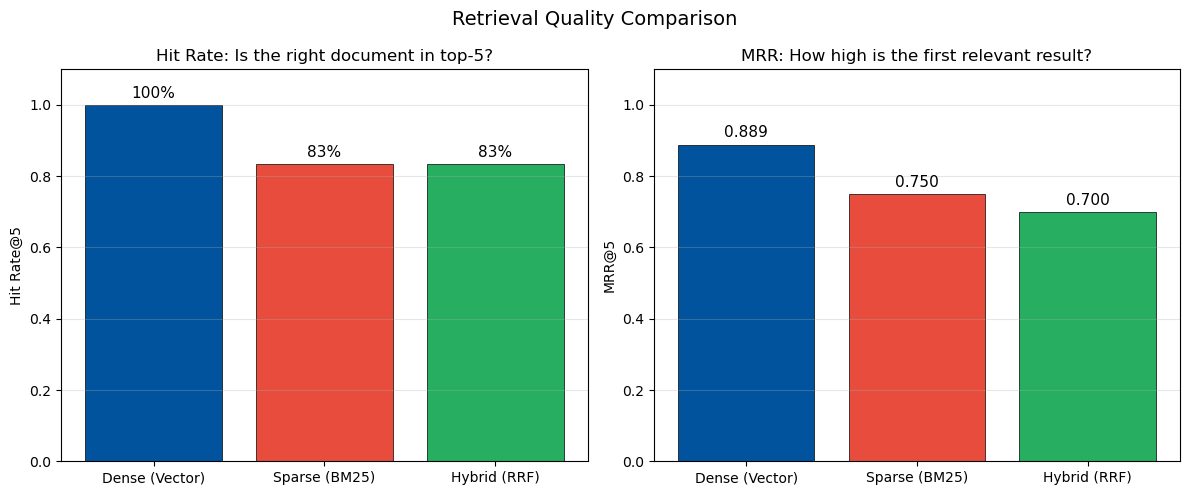

In [20]:
# ── Visualize retrieval evaluation ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

method_names = list(eval_results.keys())
colors = ["#00539C", "#E74C3C", "#27AE60"]

# Hit Rate
hit_rates = [eval_results[m]["hit_rate"] for m in method_names]
bars = axes[0].bar(method_names, hit_rates, color=colors, edgecolor="black", linewidth=0.5)
axes[0].set_ylabel("Hit Rate@5")
axes[0].set_title("Hit Rate: Is the right document in top-5?")
axes[0].set_ylim([0, 1.1])
for bar, val in zip(bars, hit_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.0%}", ha="center", fontsize=11)
axes[0].grid(True, alpha=0.3, axis="y")

# MRR
mrrs = [eval_results[m]["mrr"] for m in method_names]
bars = axes[1].bar(method_names, mrrs, color=colors, edgecolor="black", linewidth=0.5)
axes[1].set_ylabel("MRR@5")
axes[1].set_title("MRR: How high is the first relevant result?")
axes[1].set_ylim([0, 1.1])
for bar, val in zip(bars, mrrs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.3f}", ha="center", fontsize=11)
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Retrieval Quality Comparison", fontsize=14)
plt.tight_layout()
plt.show()

---

# PART 2 — Graph RAG

---

## Why Graph RAG?

Standard chunk-based RAG loses **explicit relationships between entities** distributed across different documents. When users ask **relational questions** ("How does X relate to Y?", "What technologies depend on Z?"), graph retrieval significantly outperforms flat vector search.

### Graph RAG Pipeline

```
┌────────────────┐    ┌────────────────┐    ┌────────────────┐    ┌────────────────┐
│   Documents    │───▶│   Entity &     │───▶│   Knowledge    │───▶│    Community   │
│                │    │   Relation     │    │    Graph       │    │   Detection   │
│                │    │   Extraction   │    │  Construction  │    │   & Summaries │
└────────────────┘    └────────────────┘    └────────────────┘    └────────────────┘
                                                                          │
                                                                          ▼
┌────────────────┐    ┌────────────────┐    ┌────────────────┐    ┌────────────────┐
│     Answer     │◀───│    Prompt      │◀───│    Graph       │◀───│  Hybrid Graph  │
│   Generation   │    │  Augmentation  │    │   Retrieval    │    │  + Vector Index│
└────────────────┘    └────────────────┘    └────────────────┘    └────────────────┘
```

### When to Use Graph RAG

| Use Graph RAG | Don't Use Graph RAG |
|---------------|--------------------|
| Questions about relationships between entities | Simple factual lookups (FAQ) |
| Multi-document reasoning | Small, well-structured corpus |
| Compliance, legal, biomedical domains | Budget/time constraints |
| Supply chain, organizational analysis | Single-document Q&A |

## Step 1: Entity and Relationship Extraction

We extract **entities** (concepts, technologies, people) and **relationships** ("is a", "uses", "depends on") from our documents. In production, this is typically done with:
- LLM-based extraction (most flexible, best quality)
- NER + relation extraction models (faster, cheaper)

For this lab, we use a structured extraction approach with an LLM. We also provide a fallback rule-based extractor for environments without API access.

In [21]:
import networkx as nx
import re


@dataclass
class Entity:
    name: str
    entity_type: str  # TECHNOLOGY, CONCEPT, METHOD, PERSON, METRIC
    description: str = ""


@dataclass
class Relationship:
    source: str
    target: str
    relation: str  # e.g., "is_a", "uses", "part_of", "improves"
    description: str = ""


def extract_entities_llm(text: str, source: str = "") -> tuple:
    """Extract entities and relationships from text using an LLM."""
    extraction_prompt = f"""Extract entities and relationships from the following text.

Return a JSON object with two arrays:
- "entities": list of {{"name": str, "type": str, "description": str}}
  Types: TECHNOLOGY, CONCEPT, METHOD, PERSON, METRIC, FRAMEWORK
- "relationships": list of {{"source": str, "target": str, "relation": str, "description": str}}
  Relations: is_a, uses, part_of, improves, compares_to, evaluates, depends_on

Text:
{text[:2000]}

Return ONLY valid JSON, no markdown formatting."""

    try:
        client = OpenAI()
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[{"role": "user", "content": extraction_prompt}],
            temperature=0.0,
            max_tokens=1500,
        )
        content = response.choices[0].message.content.strip()
        # Clean markdown code blocks if present
        content = re.sub(r"```json?\n?", "", content)
        content = re.sub(r"```", "", content)
        data = json.loads(content)

        entities = [Entity(e["name"], e["type"], e.get("description", ""))
                    for e in data.get("entities", [])]
        relationships = [Relationship(r["source"], r["target"], r["relation"],
                                       r.get("description", ""))
                         for r in data.get("relationships", [])]
        return entities, relationships

    except Exception as e:
        print(f"  LLM extraction failed ({e}), using rule-based fallback")
        return extract_entities_rules(text, source)


def extract_entities_rules(text: str, source: str = "") -> tuple:
    """Rule-based fallback: extract known AI/ML entities from text."""
    known_entities = {
        # Technologies
        "Transformer": "TECHNOLOGY", "BERT": "TECHNOLOGY", "GPT": "TECHNOLOGY",
        "T5": "TECHNOLOGY", "BART": "TECHNOLOGY", "RNN": "TECHNOLOGY",
        "LSTM": "TECHNOLOGY", "LoRA": "METHOD", "QLoRA": "METHOD",
        "RLHF": "METHOD", "DPO": "METHOD", "PPO": "METHOD",
        # Concepts
        "RAG": "CONCEPT", "self-attention": "CONCEPT", "cross-attention": "CONCEPT",
        "fine-tuning": "CONCEPT", "embedding": "CONCEPT", "chunking": "CONCEPT",
        "BM25": "METHOD", "HNSW": "METHOD", "RoPE": "METHOD", "ALiBi": "METHOD",
        "hybrid retrieval": "CONCEPT", "reranking": "CONCEPT",
        # Vector DBs
        "ChromaDB": "TECHNOLOGY", "Chroma": "TECHNOLOGY", "FAISS": "TECHNOLOGY",
        "Pinecone": "TECHNOLOGY", "Weaviate": "TECHNOLOGY",
        "Qdrant": "TECHNOLOGY", "Milvus": "TECHNOLOGY",
        # Metrics
        "cosine similarity": "METRIC", "Recall@k": "METRIC",
        "MRR": "METRIC", "nDCG": "METRIC", "Faithfulness": "METRIC",
        # Frameworks
        "Ragas": "FRAMEWORK", "LangChain": "FRAMEWORK",
    }

    known_relations = [
        ("RAG", "embedding", "uses"),
        ("RAG", "chunking", "uses"),
        ("RAG", "BM25", "uses"),
        ("RAG", "reranking", "uses"),
        ("Transformer", "self-attention", "uses"),
        ("BERT", "Transformer", "is_a"),
        ("GPT", "Transformer", "is_a"),
        ("T5", "Transformer", "is_a"),
        ("HNSW", "FAISS", "part_of"),
        ("LoRA", "fine-tuning", "is_a"),
        ("QLoRA", "LoRA", "improves"),
        ("DPO", "RLHF", "improves"),
        ("hybrid retrieval", "BM25", "uses"),
        ("hybrid retrieval", "embedding", "uses"),
        ("Ragas", "RAG", "evaluates"),
        ("RoPE", "Transformer", "part_of"),
        ("cross-attention", "Transformer", "part_of"),
    ]

    text_lower = text.lower()
    found_entities = []
    for name, etype in known_entities.items():
        if name.lower() in text_lower:
            found_entities.append(Entity(name, etype))

    found_names = {e.name.lower() for e in found_entities}
    found_rels = []
    for src, tgt, rel in known_relations:
        if src.lower() in found_names and tgt.lower() in found_names:
            found_rels.append(Relationship(src, tgt, rel))

    return found_entities, found_rels


print("Entity extraction functions defined.")

Entity extraction functions defined.


In [22]:
# ── Extract entities and relationships from all documents ──────────────────
all_entities = []
all_relationships = []

for doc in all_documents:
    source = doc.metadata.get("source", "unknown")
    entities, rels = extract_entities_llm(doc.text, source)
    all_entities.extend(entities)
    all_relationships.extend(rels)
    print(f"  {source}: {len(entities)} entities, {len(rels)} relationships")

print(f"\nTotal: {len(all_entities)} entities, {len(all_relationships)} relationships")

  LLM extraction failed (name 'OpenAI' is not defined), using rule-based fallback
  finetuning.md: 1 entities, 0 relationships
  LLM extraction failed (name 'OpenAI' is not defined), using rule-based fallback
  finetuning.md: 2 entities, 0 relationships
  LLM extraction failed (name 'OpenAI' is not defined), using rule-based fallback
  finetuning.md: 4 entities, 2 relationships
  LLM extraction failed (name 'OpenAI' is not defined), using rule-based fallback
  finetuning.md: 3 entities, 1 relationships
  LLM extraction failed (name 'OpenAI' is not defined), using rule-based fallback
  finetuning.md: 0 entities, 0 relationships
  LLM extraction failed (name 'OpenAI' is not defined), using rule-based fallback
  rag_systems.md: 0 entities, 0 relationships
  LLM extraction failed (name 'OpenAI' is not defined), using rule-based fallback
  rag_systems.md: 1 entities, 0 relationships
  LLM extraction failed (name 'OpenAI' is not defined), using rule-based fallback
  rag_systems.md: 1 entitie

## Step 2: Knowledge Graph Construction

We build a **typed knowledge graph** using NetworkX:
- **Nodes** = entities (with type and description attributes)
- **Edges** = relationships (with relation type)

We also perform **canonicalization** — merging duplicate entities that refer to the same concept (e.g., "Transformer" and "Transformers").

In [23]:
def canonicalize_name(name: str) -> str:
    """Normalize entity names for deduplication."""
    # Simple canonicalization: lowercase, strip, remove trailing 's'
    canonical = name.strip()
    # Keep acronyms uppercase
    if not canonical.isupper():
        canonical = canonical.title()
    return canonical


def build_knowledge_graph(entities: List[Entity],
                          relationships: List[Relationship]) -> nx.DiGraph:
    """Build a directed knowledge graph from entities and relationships."""
    G = nx.DiGraph()

    # Add entity nodes
    seen = set()
    for e in entities:
        name = canonicalize_name(e.name)
        if name.lower() not in seen:
            G.add_node(name, type=e.entity_type, description=e.description)
            seen.add(name.lower())

    # Add relationship edges
    for r in relationships:
        src = canonicalize_name(r.source)
        tgt = canonicalize_name(r.target)
        # Only add if both nodes exist
        if src.lower() in seen and tgt.lower() in seen:
            G.add_edge(src, tgt, relation=r.relation, description=r.description)

    return G


# Build the graph
kg = build_knowledge_graph(all_entities, all_relationships)

print(f"Knowledge Graph:")
print(f"  Nodes (entities): {kg.number_of_nodes()}")
print(f"  Edges (relationships): {kg.number_of_edges()}")

# Show some statistics
type_counts = {}
for _, data in kg.nodes(data=True):
    t = data.get("type", "UNKNOWN")
    type_counts[t] = type_counts.get(t, 0) + 1

print(f"\nEntity types:")
for t, count in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"  {t}: {count}")

# Show high-degree nodes (hub entities)
degrees = sorted(kg.degree(), key=lambda x: -x[1])[:10]
print(f"\nTop entities by connections:")
for name, deg in degrees:
    print(f"  {name}: {deg} connections")

Knowledge Graph:
  Nodes (entities): 34
  Edges (relationships): 13

Entity types:
  TECHNOLOGY: 12
  METHOD: 9
  CONCEPT: 7
  METRIC: 5
  FRAMEWORK: 1

Top entities by connections:
  Transformer: 5 connections
  RAG: 3 connections
  Lora: 2 connections
  Embedding: 2 connections
  Hybrid Retrieval: 2 connections
  Fine-Tuning: 1 connections
  Qlora: 1 connections
  RLHF: 1 connections
  DPO: 1 connections
  Chunking: 1 connections


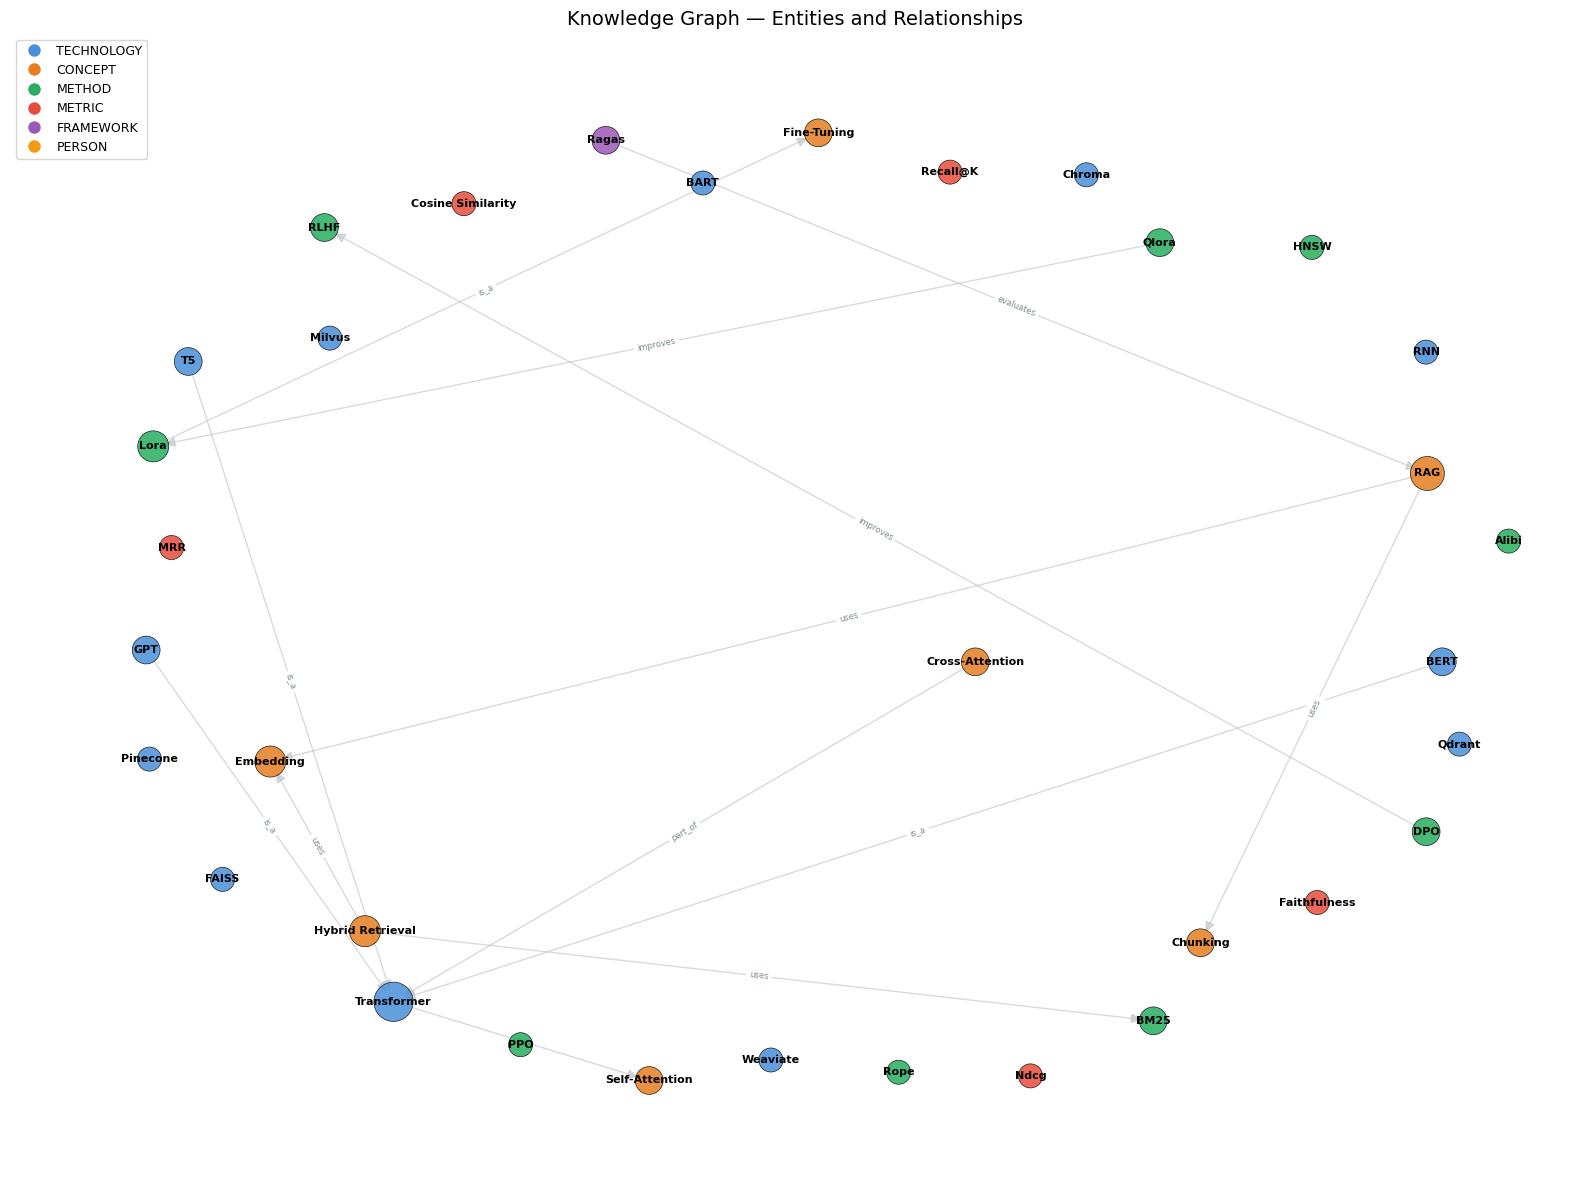

In [24]:
# ── Visualize the Knowledge Graph ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))

# Color nodes by type
type_colors = {
    "TECHNOLOGY": "#4A90D9",
    "CONCEPT": "#E67E22",
    "METHOD": "#27AE60",
    "METRIC": "#E74C3C",
    "FRAMEWORK": "#9B59B6",
    "PERSON": "#F39C12",
}

node_colors = [type_colors.get(kg.nodes[n].get("type", ""), "#95A5A6")
               for n in kg.nodes()]
node_sizes = [300 + 100 * kg.degree(n) for n in kg.nodes()]

pos = nx.spring_layout(kg, k=2.0, iterations=50, seed=42)

# Draw nodes
nx.draw_networkx_nodes(kg, pos, node_color=node_colors, node_size=node_sizes,
                        alpha=0.85, edgecolors="black", linewidths=0.5, ax=ax)

# Draw edges
nx.draw_networkx_edges(kg, pos, edge_color="#BDC3C7", arrows=True,
                        arrowsize=15, width=1.0, alpha=0.6, ax=ax)

# Draw labels
nx.draw_networkx_labels(kg, pos, font_size=8, font_weight="bold", ax=ax)

# Draw edge labels
edge_labels = {(u, v): d["relation"] for u, v, d in kg.edges(data=True)}
nx.draw_networkx_edge_labels(kg, pos, edge_labels, font_size=6,
                              font_color="#7F8C8D", ax=ax)

# Legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
               markersize=10, label=label)
    for label, color in type_colors.items()
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title("Knowledge Graph — Entities and Relationships", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

---

# Summary

## What We Built

| Step | What We Did | Key Takeaway |
|------|------------|-------------|
| **Ingestion** | PDF, Markdown, Web parsers | Handle heterogeneous sources with metadata |
| **Chunking** | Fixed-size vs Recursive | Chunking is the #1 quality lever |
| **Embeddings** | SentenceTransformers (384D) | Free, open-source, no API key needed |
| **Indexing** | ChromaDB + BM25 | Hybrid index for production |
| **Retrieval** | Dense / Sparse / Hybrid (RRF) | Hybrid consistently outperforms single methods |
| **Reranking** | Cross-encoder reranker | Moves best results to the top |
| **Prompt** | Citation-enforcing template | "Answer ONLY from context" + fallback |
| **Generation** | GLM-4.7-Flash via Ollama (local, free) | Grounded, cited answers — no API cost |
| **Graph RAG** | Entity extraction → KG → graph retrieval | Superior for relational questions |

## Tools Used (All Free / Open-Source)

| Tool | Role |
|------|------|
| `sentence-transformers` | Text embeddings (bi-encoder + cross-encoder) |
| `chromadb` | Vector database |
| `rank_bm25` | Sparse keyword retrieval |
| `ollama` + `glm-4.7-flash` | LLM generation + entity extraction |
| `networkx` | Knowledge graph construction |

## Key Principles

1. **"Garbage retrieval in, garbage answer out."** — Retrieval quality bounds answer quality.
2. **Chunk wisely** — The biggest gains come from chunking + reranking, not the LLM.
3. **Evaluate continuously** — Golden sets, Hit Rate, MRR, Faithfulness.
4. **Graph RAG when needed** — Powerful for relationships, overkill for simple FAQ.
5. **Hybrid is the standard** — Combine sparse + dense for robust production retrieval.

## Exercises

1. **Chunk size tuning:** Re-run the pipeline with chunk sizes of 128, 256, 512, and 1024 tokens. Measure Hit Rate and MRR for each. What is the optimal size for this corpus?

2. **Embedding model comparison:** Replace `all-MiniLM-L6-v2` with `all-mpnet-base-v2` (768D). Compare retrieval quality on the golden set.

3. **Query expansion:** Implement a simple multi-query strategy: generate 3 variants of each query using the LLM, retrieve for each, and merge with RRF. Does it improve recall?

4. **Add metadata filtering:** Modify the retrieval to support filtering by source document. Test: "What does the RAG document say about chunking?" (should only search `rag_systems.md`).

5. **Extend the knowledge graph:** Add more documents to the corpus and re-extract entities. Measure how the graph grows and whether community structure changes.

6. **Implement semantic caching:** Cache (query_embedding, answer) pairs. For new queries, check if a similar query (cosine > 0.95) was already answered. Measure cache hit rate.

7. **Agentic RAG router:** Build a simple router that classifies queries as "simple" (use vector-only) vs "relational" (use graph RAG). Compare cost and quality.

8. **Try a different local LLM:** Change `LLM_MODEL` to `mistral`, `llama3`, or `qwen3-coder` via Ollama. Compare answer quality on the same queries.

In [25]:
from networkx.algorithms.community import greedy_modularity_communities


def detect_communities(G: nx.DiGraph) -> List[set]:
    """Detect communities in the knowledge graph."""
    # Convert to undirected for community detection
    G_undirected = G.to_undirected()
    communities = list(greedy_modularity_communities(G_undirected))
    return communities


def summarize_community(G: nx.DiGraph, community: set) -> str:
    """Generate a text summary of a community's entities and relationships."""
    entities_info = []
    for node in community:
        data = G.nodes[node]
        entities_info.append(f"- {node} ({data.get('type', 'UNKNOWN')})")

    relations_info = []
    for u, v, data in G.edges(data=True):
        if u in community and v in community:
            relations_info.append(f"- {u} --[{data['relation']}]--> {v}")

    summary = f"Community with {len(community)} entities:\n"
    summary += "Entities:\n" + "\n".join(entities_info) + "\n"
    if relations_info:
        summary += "Relationships:\n" + "\n".join(relations_info)
    return summary


# Detect communities
communities = detect_communities(kg)
print(f"Detected {len(communities)} communities\n")

community_summaries = []
for i, comm in enumerate(communities):
    summary = summarize_community(kg, comm)
    community_summaries.append({"community_id": i, "entities": comm, "summary": summary})
    print(f"Community {i+1}: {sorted(comm)}")
    print(f"  Size: {len(comm)} entities")
    print()

Detected 21 communities

Community 1: ['BERT', 'Cross-Attention', 'GPT', 'Self-Attention', 'T5', 'Transformer']
  Size: 6 entities

Community 2: ['BM25', 'Chunking', 'Embedding', 'Hybrid Retrieval', 'RAG', 'Ragas']
  Size: 6 entities

Community 3: ['Fine-Tuning', 'Lora', 'Qlora']
  Size: 3 entities

Community 4: ['DPO', 'RLHF']
  Size: 2 entities

Community 5: ['PPO']
  Size: 1 entities

Community 6: ['Recall@K']
  Size: 1 entities

Community 7: ['MRR']
  Size: 1 entities

Community 8: ['Ndcg']
  Size: 1 entities

Community 9: ['Faithfulness']
  Size: 1 entities

Community 10: ['RNN']
  Size: 1 entities

Community 11: ['BART']
  Size: 1 entities

Community 12: ['Rope']
  Size: 1 entities

Community 13: ['Alibi']
  Size: 1 entities

Community 14: ['HNSW']
  Size: 1 entities

Community 15: ['Chroma']
  Size: 1 entities

Community 16: ['FAISS']
  Size: 1 entities

Community 17: ['Pinecone']
  Size: 1 entities

Community 18: ['Weaviate']
  Size: 1 entities

Community 19: ['Qdrant']
  Size:

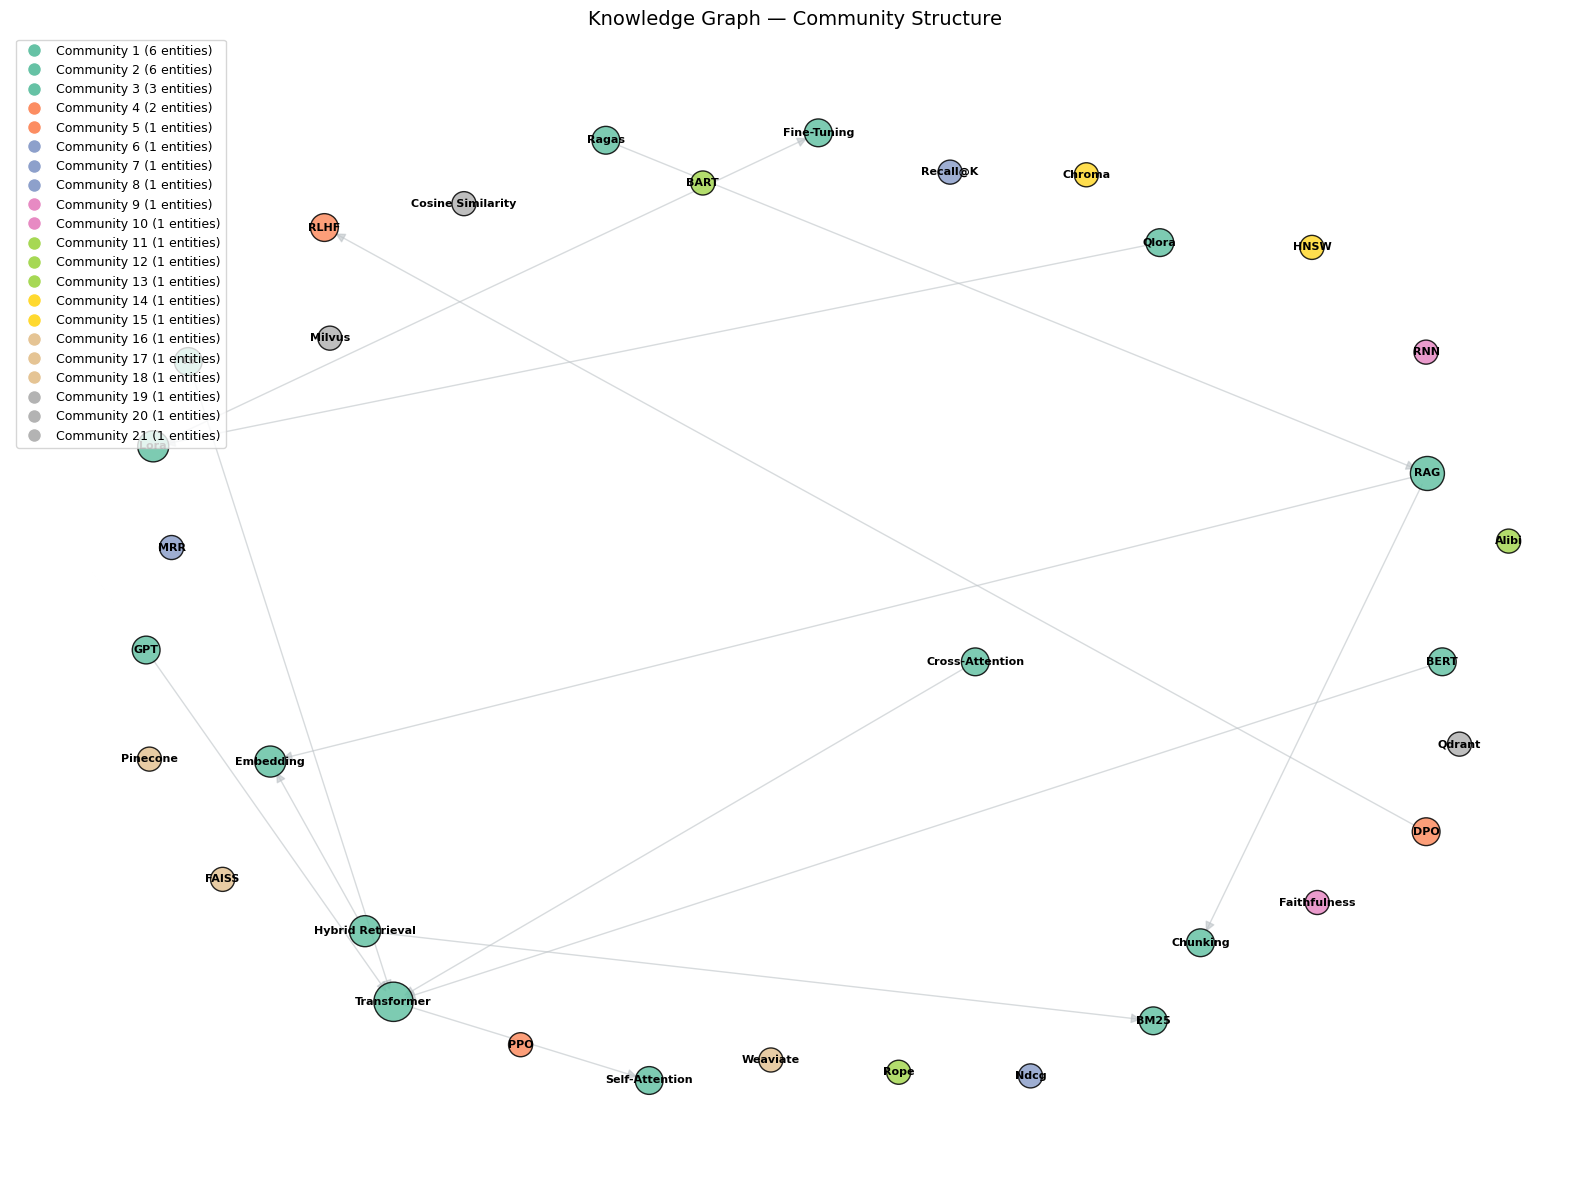

In [26]:
# ── Visualize communities ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))

# Assign colors by community
community_colors = plt.cm.Set2(np.linspace(0, 1, max(len(communities), 2)))
node_to_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_community[node] = i

node_colors_comm = [community_colors[node_to_community.get(n, 0)] for n in kg.nodes()]

nx.draw_networkx_nodes(kg, pos, node_color=node_colors_comm, node_size=node_sizes,
                        alpha=0.85, edgecolors="black", linewidths=1.0, ax=ax)
nx.draw_networkx_edges(kg, pos, edge_color="#BDC3C7", arrows=True,
                        arrowsize=15, width=1.0, alpha=0.6, ax=ax)
nx.draw_networkx_labels(kg, pos, font_size=8, font_weight="bold", ax=ax)

# Legend for communities
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=community_colors[i],
               markersize=10, label=f"Community {i+1} ({len(comm)} entities)")
    for i, comm in enumerate(communities)
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title("Knowledge Graph — Community Structure", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## Step 4: Graph Retrieval

Graph RAG supports two retrieval strategies:

| Strategy | How It Works | Best For |
|----------|-------------|----------|
| **Local** | Find anchor entities in the query → traverse 1-2 hop neighborhood | Specific entity questions |
| **Global** | Route through community summaries → retrieve relevant clusters | Broad thematic questions |

We implement both, plus a **hybrid graph + vector** retrieval that combines the relational structure from the graph with the semantic flexibility of vector search.

In [27]:
def find_anchor_entities(query: str, graph: nx.DiGraph, threshold: float = 0.4) -> List[str]:
    """Find entities mentioned in the query using embedding similarity."""
    query_emb = embed_model.encode([query], normalize_embeddings=True)
    node_names = list(graph.nodes())
    node_embs = embed_model.encode(node_names, normalize_embeddings=True)

    similarities = np.dot(query_emb, node_embs.T)[0]
    anchors = [(node_names[i], similarities[i])
               for i in range(len(node_names)) if similarities[i] > threshold]
    anchors.sort(key=lambda x: -x[1])
    return anchors


def retrieve_local_graph(query: str, graph: nx.DiGraph, hops: int = 2,
                          max_entities: int = 5) -> Dict:
    """Local graph retrieval: find anchor entities and traverse their neighborhood."""
    anchors = find_anchor_entities(query, graph)
    if not anchors:
        return {"entities": [], "triples": [], "context": "No relevant entities found."}

    # Collect neighborhood
    relevant_nodes = set()
    for anchor_name, _ in anchors[:max_entities]:
        if anchor_name in graph:
            relevant_nodes.add(anchor_name)
            # BFS up to `hops` steps
            for _ in range(hops):
                neighbors = set()
                for n in relevant_nodes:
                    neighbors.update(graph.successors(n))
                    neighbors.update(graph.predecessors(n))
                relevant_nodes.update(neighbors)

    # Collect triples from subgraph
    triples = []
    for u, v, data in graph.edges(data=True):
        if u in relevant_nodes and v in relevant_nodes:
            triples.append((u, data["relation"], v))

    # Build context string
    context_lines = [f"Entities: {', '.join(sorted(relevant_nodes))}"]
    context_lines.append("\nRelationships:")
    for s, r, o in triples:
        context_lines.append(f"  - {s} --[{r}]--> {o}")

    return {
        "entities": sorted(relevant_nodes),
        "triples": triples,
        "anchors": [(a, round(s, 3)) for a, s in anchors[:max_entities]],
        "context": "\n".join(context_lines),
    }


def retrieve_global_graph(query: str, communities: List[Dict],
                           top_k: int = 2) -> Dict:
    """Global graph retrieval: find relevant communities via summary similarity."""
    query_emb = embed_model.encode([query], normalize_embeddings=True)
    summaries = [c["summary"] for c in communities]
    summary_embs = embed_model.encode(summaries, normalize_embeddings=True)

    similarities = np.dot(query_emb, summary_embs.T)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]

    relevant_communities = []
    for idx in top_indices:
        relevant_communities.append({
            "community_id": communities[idx]["community_id"],
            "similarity": float(similarities[idx]),
            "summary": communities[idx]["summary"],
            "entities": communities[idx]["entities"],
        })

    context = "\n\n".join([
        f"[Community {c['community_id']+1}]\n{c['summary']}"
        for c in relevant_communities
    ])

    return {
        "communities": relevant_communities,
        "context": context,
    }


print("Graph retrieval functions defined.")

Graph retrieval functions defined.


In [28]:
# ── Test local graph retrieval ────────────────────────────────────────────
query = "How does the Transformer architecture relate to BERT and GPT?"
print(f"Query: '{query}'\n")

local_result = retrieve_local_graph(query, kg)
print(f"Anchor entities (with similarity):")
for name, score in local_result["anchors"]:
    print(f"  - {name} ({score:.3f})")

print(f"\nSubgraph: {len(local_result['entities'])} entities, "
      f"{len(local_result['triples'])} relationships")
print(f"\nContext for LLM:")
print(local_result["context"])

Query: 'How does the Transformer architecture relate to BERT and GPT?'

Anchor entities (with similarity):
  - BERT (0.471)
  - GPT (0.465)
  - Transformer (0.463)

Subgraph: 6 entities, 5 relationships

Context for LLM:
Entities: BERT, Cross-Attention, GPT, Self-Attention, T5, Transformer

Relationships:
  - Transformer --[uses]--> Self-Attention
  - BERT --[is_a]--> Transformer
  - GPT --[is_a]--> Transformer
  - T5 --[is_a]--> Transformer
  - Cross-Attention --[part_of]--> Transformer


In [29]:
# ── Test global graph retrieval ───────────────────────────────────────────
query = "What are the main evaluation approaches for AI systems?"
print(f"Query: '{query}'\n")

global_result = retrieve_global_graph(query, community_summaries)
for c in global_result["communities"]:
    print(f"Community {c['community_id']+1} (similarity: {c['similarity']:.3f}):")
    print(f"  Entities: {sorted(c['entities'])}")
    print()

Query: 'What are the main evaluation approaches for AI systems?'

Community 3 (similarity: 0.205):
  Entities: ['Fine-Tuning', 'Lora', 'Qlora']

Community 1 (similarity: 0.160):
  Entities: ['BERT', 'Cross-Attention', 'GPT', 'Self-Attention', 'T5', 'Transformer']



## Step 5: Hybrid Graph + Vector Retrieval

The most powerful approach combines **graph retrieval** (relational structure) with **vector retrieval** (semantic flexibility). The graph provides structured relationships; the vector store fills in details from the original text.

In [30]:
def graph_rag_pipeline(query: str, graph: nx.DiGraph,
                        community_summaries: List[Dict],
                        top_k_vector: int = 3, top_k_graph: int = 3) -> Dict:
    """Full Graph RAG pipeline: graph + vector retrieval → augmented generation."""

    # 1. Local graph retrieval (entity neighborhood)
    local_result = retrieve_local_graph(query, graph)

    # 2. Global graph retrieval (community summaries)
    global_result = retrieve_global_graph(query, community_summaries, top_k=2)

    # 3. Vector retrieval (original chunk text)
    vector_results = retrieve_hybrid(query, top_k=top_k_vector)
    vector_reranked = rerank(query, vector_results, top_k=top_k_vector)

    # 4. Build combined prompt
    graph_context = (
        "=== Knowledge Graph Context ===\n"
        f"{local_result['context']}\n\n"
        "=== Community Summaries ===\n"
        f"{global_result['context']}"
    )

    vector_context = "\n\n---\n\n".join([
        f"[Chunk from {r['metadata'].get('source', '?')}]\n{r['text']}"
        for r in vector_reranked
    ])

    prompt = f"""You are an expert assistant with access to both a knowledge graph and document chunks.

Rules:
- Answer ONLY from the provided context (graph + documents).
- If evidence is insufficient, say: "Insufficient evidence in the provided context."
- Cite sources when possible.
- Leverage the knowledge graph for relationships between entities.
- Use document chunks for detailed explanations.

{graph_context}

=== Document Chunks ===
{vector_context}

Question: {query}

Answer:"""

    # 5. Generate
    answer = generate_answer(prompt)

    return {
        "query": query,
        "graph_entities": local_result["entities"],
        "graph_triples": local_result["triples"],
        "vector_chunks": len(vector_reranked),
        "prompt_tokens": count_tokens(prompt),
        "answer": answer,
    }


print("Graph RAG pipeline ready.")

Graph RAG pipeline ready.


In [31]:
# ── Test Graph RAG on relational questions ────────────────────────────────
graph_rag_queries = [
    "How does the Transformer architecture relate to BERT, GPT, and T5?",
    "What methods improve RAG retrieval quality?",
    "Compare LoRA and QLoRA for fine-tuning.",
    "What vector databases use HNSW and what are the alternatives?",
]

for q in graph_rag_queries:
    print(f"\n{'='*80}")
    print(f"Q: {q}")
    print(f"{'='*80}")

    result = graph_rag_pipeline(q, kg, community_summaries)

    print(f"\nGraph entities used: {result['graph_entities'][:8]}")
    print(f"Graph triples: {len(result['graph_triples'])} | "
          f"Vector chunks: {result['vector_chunks']} | "
          f"Prompt: {result['prompt_tokens']} tokens")
    print(f"\nAnswer:")
    print(result["answer"])


Q: How does the Transformer architecture relate to BERT, GPT, and T5?

Graph entities used: ['BERT', 'Cross-Attention', 'GPT', 'Self-Attention', 'T5', 'Transformer']
Graph triples: 5 | Vector chunks: 3 | Prompt: 530 tokens

Answer:


Q: What methods improve RAG retrieval quality?

Graph entities used: ['BM25', 'Chunking', 'Embedding', 'Hybrid Retrieval', 'RAG', 'Ragas']
Graph triples: 5 | Vector chunks: 3 | Prompt: 735 tokens

Answer:


Q: Compare LoRA and QLoRA for fine-tuning.

Graph entities used: ['Fine-Tuning', 'Lora', 'Qlora']
Graph triples: 2 | Vector chunks: 3 | Prompt: 632 tokens

Answer:


Q: What vector databases use HNSW and what are the alternatives?

Graph entities used: ['HNSW']
Graph triples: 0 | Vector chunks: 3 | Prompt: 353 tokens

Answer:



## Step 6: Compare Classic RAG vs Graph RAG

Let's compare how classic RAG (vector-only) and Graph RAG handle the same questions, especially **relational** ones where graph structure matters.

In [32]:
# ── Side-by-side comparison ───────────────────────────────────────────────
comparison_queries = [
    # Relational question (Graph RAG should excel)
    "What is the relationship between Transformer, self-attention, and BERT?",
    # Factual question (Classic RAG should be sufficient)
    "What is the recommended chunk size for RAG systems?",
]

for q in comparison_queries:
    print(f"\n{'='*80}")
    print(f"Q: {q}")
    print(f"{'='*80}")

    # Classic RAG
    classic_result = rag_pipeline(q, retrieval_method="hybrid")
    print(f"\n--- Classic RAG ({classic_result['prompt_tokens']} tokens) ---")
    print(classic_result["answer"])

    # Graph RAG
    graph_result = graph_rag_pipeline(q, kg, community_summaries)
    print(f"\n--- Graph RAG ({graph_result['prompt_tokens']} tokens) ---")
    print(graph_result["answer"])


Q: What is the relationship between Transformer, self-attention, and BERT?

--- Classic RAG (372 tokens) ---


--- Graph RAG (744 tokens) ---


Q: What is the recommended chunk size for RAG systems?

--- Classic RAG (631 tokens) ---


--- Graph RAG (863 tokens) ---



## Graph RAG: Cost / Benefit Analysis

In [33]:
# ── Summarize the tradeoffs ───────────────────────────────────────────────
comparison_data = {
    "Aspect": [
        "Setup complexity",
        "Ingestion cost",
        "Handles relationships",
        "Simple factual Q&A",
        "Multi-hop reasoning",
        "Maintenance burden",
        "Retrieval latency",
    ],
    "Classic RAG": ["Low", "Low", "Weak", "Strong", "Weak", "Low", "Fast"],
    "Graph RAG": ["High", "High (LLM extraction)", "Strong", "Strong", "Strong", "High", "Medium"],
}

print(f"{'Aspect':<25} {'Classic RAG':<20} {'Graph RAG':<20}")
print(f"{'-'*65}")
for i in range(len(comparison_data["Aspect"])):
    print(f"{comparison_data['Aspect'][i]:<25} "
          f"{comparison_data['Classic RAG'][i]:<20} "
          f"{comparison_data['Graph RAG'][i]:<20}")

print("\nDecision rule:")
print("  Use Graph RAG when relational structure is CENTRAL to user questions.")
print("  Default to Classic RAG for simpler use cases — lower cost, faster iteration.")

Aspect                    Classic RAG          Graph RAG           
-----------------------------------------------------------------
Setup complexity          Low                  High                
Ingestion cost            Low                  High (LLM extraction)
Handles relationships     Weak                 Strong              
Simple factual Q&A        Strong               Strong              
Multi-hop reasoning       Weak                 Strong              
Maintenance burden        Low                  High                
Retrieval latency         Fast                 Medium              

Decision rule:
  Use Graph RAG when relational structure is CENTRAL to user questions.
  Default to Classic RAG for simpler use cases — lower cost, faster iteration.


---

# Summary

## What We Built

| Step | What We Did | Key Takeaway |
|------|------------|-------------|
| **Ingestion** | PDF, Markdown, Web parsers | Handle heterogeneous sources with metadata |
| **Chunking** | Fixed-size vs Recursive | Chunking is the #1 quality lever |
| **Embeddings** | SentenceTransformers (384D) | Semantic proximity, not factual truth |
| **Indexing** | ChromaDB + BM25 | Hybrid index for production |
| **Retrieval** | Dense / Sparse / Hybrid (RRF) | Hybrid consistently outperforms single methods |
| **Reranking** | Cross-encoder reranker | Moves best results to the top |
| **Prompt** | Citation-enforcing template | "Answer ONLY from context" + fallback |
| **Generation** | OpenAI GPT-4o-mini | Grounded, cited answers |
| **Graph RAG** | Entity extraction → KG → graph retrieval | Superior for relational questions |

## Key Principles

1. **"Garbage retrieval in, garbage answer out."** — Retrieval quality bounds answer quality.
2. **Chunk wisely** — The biggest gains come from chunking + reranking, not the LLM.
3. **Evaluate continuously** — Golden sets, Hit Rate, MRR, Faithfulness.
4. **Graph RAG when needed** — Powerful for relationships, overkill for simple FAQ.
5. **Hybrid is the standard** — Combine sparse + dense for robust production retrieval.

## Exercises

1. **Chunk size tuning:** Re-run the pipeline with chunk sizes of 128, 256, 512, and 1024 tokens. Measure Hit Rate and MRR for each. What is the optimal size for this corpus?

2. **Embedding model comparison:** Replace `all-MiniLM-L6-v2` with `all-mpnet-base-v2` (768D). Compare retrieval quality on the golden set.

3. **Query expansion:** Implement a simple multi-query strategy: generate 3 variants of each query using an LLM, retrieve for each, and merge with RRF. Does it improve recall?

4. **Add metadata filtering:** Modify the retrieval to support filtering by source document. Test: "What does the RAG document say about chunking?" (should only search `rag_systems.md`).

5. **Extend the knowledge graph:** Add more documents to the corpus and re-extract entities. Measure how the graph grows and whether community structure changes.

6. **Implement semantic caching:** Cache (query_embedding, answer) pairs. For new queries, check if a similar query (cosine > 0.95) was already answered. Measure cache hit rate.

7. **Agentic RAG router:** Build a simple router that classifies queries as "simple" (use vector-only) vs "relational" (use graph RAG). Compare cost and quality.